In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2021.csv")

In [17]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})


missing = missing[missing["Missing Values"] > 0]

print(missing.sort_values(by="Missing Values", ascending=False))

Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


In [18]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 12828


In [19]:
df_cleaned = df.drop_duplicates(keep='first')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

Original shape: (236378, 22)
Cleaned shape: (223550, 22)


In [20]:
print(df_cleaned["Diabetes_012"].value_counts())

Diabetes_012
0.0    184542
2.0     33395
1.0      5613
Name: count, dtype: int64


In [24]:
df_binary = df_cleaned[df_cleaned["Diabetes_012"].isin([0, 2])].copy()
print(df_binary["Diabetes_012"].value_counts())
print("\nFinal shape:", df_binary.shape)

Diabetes_012
0.0    184542
2.0     33395
Name: count, dtype: int64

Final shape: (217937, 22)


In [25]:
df_binary["Diabetes_012"] = df_binary["Diabetes_012"].replace({
    2: 1
})
print(df_binary["Diabetes_012"].value_counts())

Diabetes_012
0.0    184542
1.0     33395
Name: count, dtype: int64


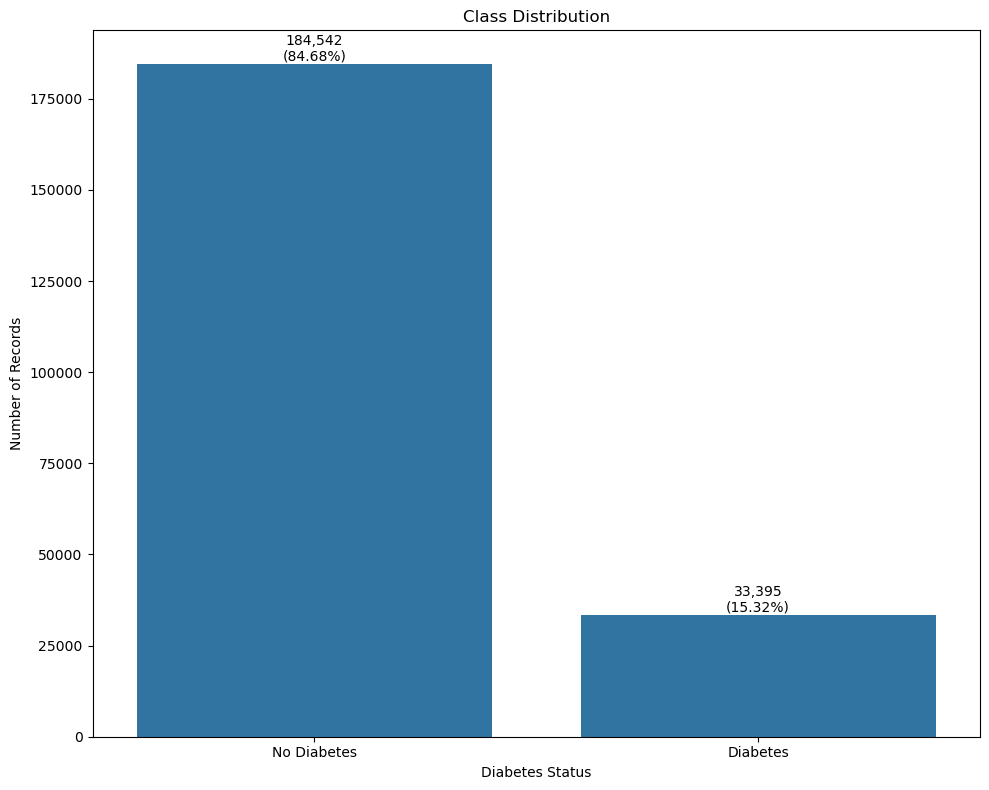

In [33]:
plt.figure(figsize=(10, 8))
ax = sns.countplot(
    data=df_binary,
    x="Diabetes_012"
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Diabetes", "Diabetes"])
total = len(df_binary)
for container in ax.containers:
    for bar in container:
        count = int(bar.get_height())
        percentage = (count / total) * 100  
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count:,}\n({percentage:.2f}%)",
            ha="center",
            va="bottom",
        )
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Records")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

In [9]:
df_binary.to_csv("cleaned_binary_dataset.csv",index=False)
print("Saved successfully.")
print("File: cleaned_binary_dataset.csv")

Saved successfully.
File: cleaned_binary_dataset.csv


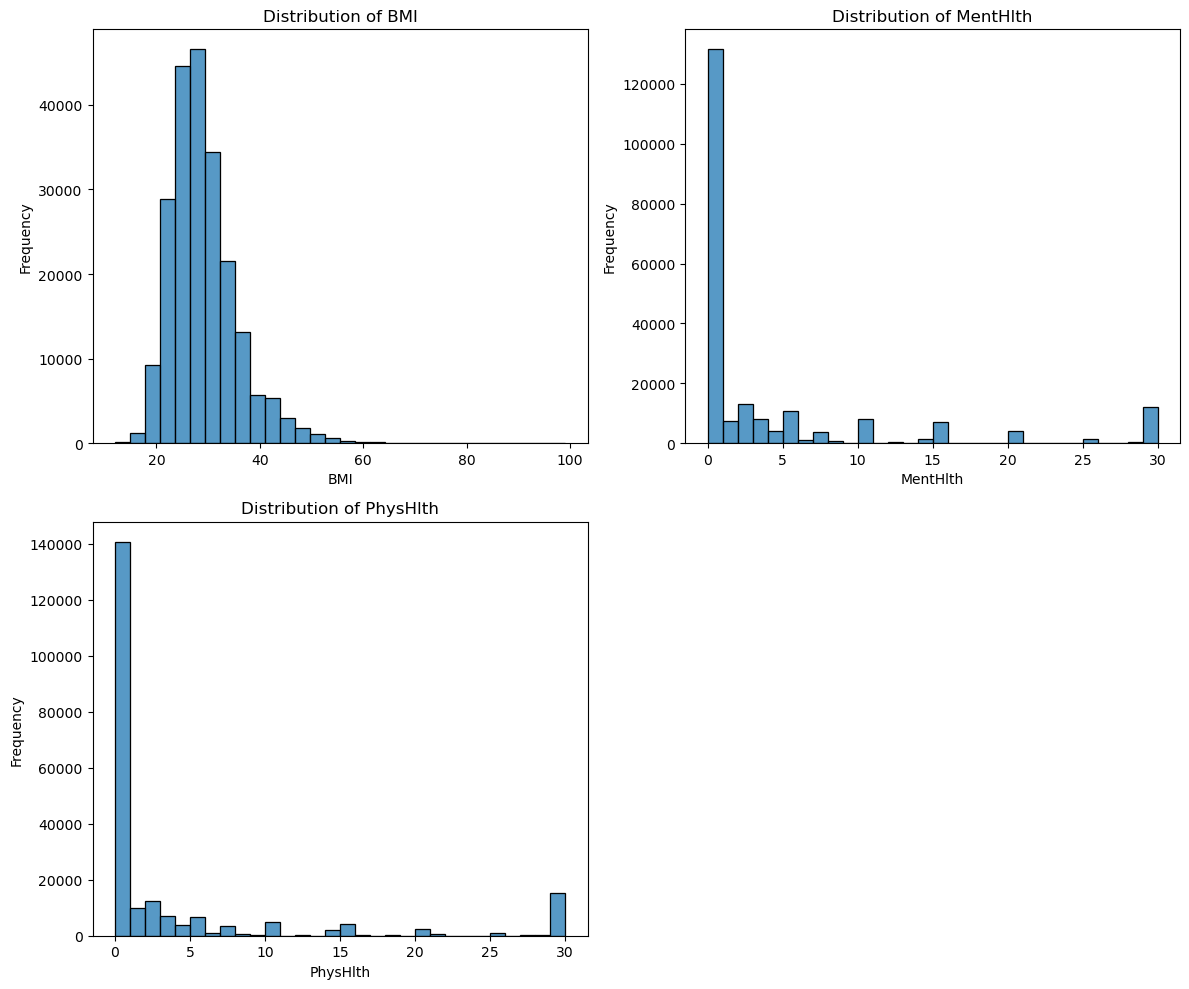

In [10]:
continuous_features = [
    "BMI",
    "MentHlth",
    "PhysHlth"
]

plt.figure(figsize=(12,10))

for i, col in enumerate(continuous_features, 1):
    plt.subplot(2,2,i)
    sns.histplot(
        data=df_binary,
        x=col,
        bins=30,
        kde=False
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

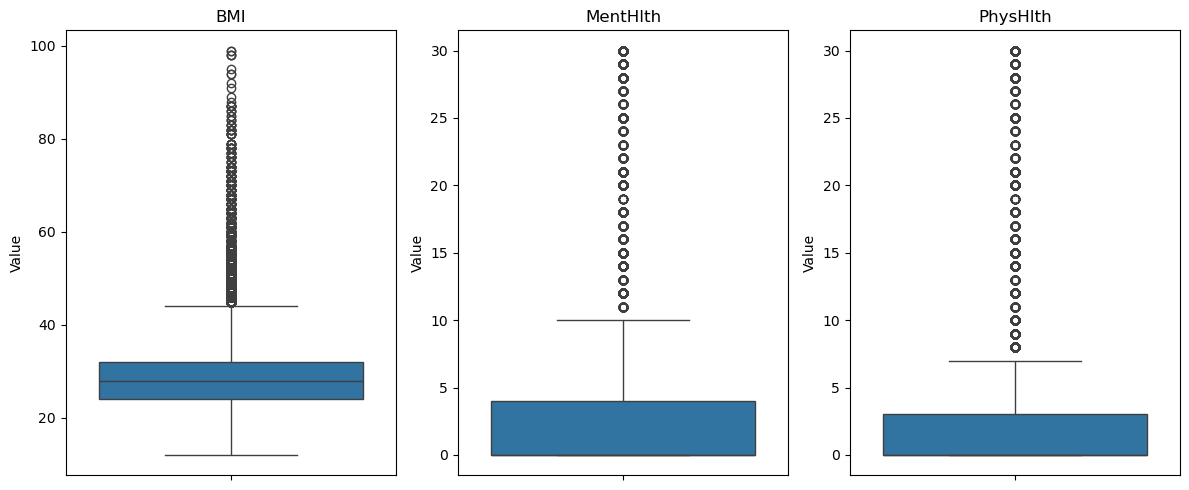

In [13]:
fig, axes = plt.subplots(
    1,
    len(continuous_features),
    figsize=(12, 5)
)

for ax, col in zip(
    axes,
    continuous_features
):

    sns.boxplot(
        y=df_binary[col],
        ax=ax
    )

    ax.set_title(
        col,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [14]:
outlier_summary = []
for col in continuous_features:
    Q1 = df_binary[col].quantile(0.25)
    Q3 = df_binary[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - 1.5 * IQR)
    upper = Q3 + 1.5 * IQR
    outliers = ((df_binary[col] < lower) | (df_binary[col] > upper)).sum()
    outlier_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2)
    })
print(pd.DataFrame(outlier_summary))

    Feature  Outliers  Lower Bound  Upper Bound
0       BMI      6014         12.0         44.0
1  MentHlth     28278          0.0         10.0
2  PhysHlth     32820          0.0          7.5


In [59]:
skewness = df_binary[continuous_features].skew()
print(skewness)

BMI         1.319617
MentHlth    2.239468
PhysHlth    2.345380
dtype: float64
